# EDA — Parte 1: Análisis del target y columnas asociadas
**Análisis Predictivo — ITBA 2026**

Fuente: `data/raw/bgg_rankings.csv` (snapshot beefsack 2026-07-01)  
Columnas disponibles: `ID`, `Name`, `Year`, `Rank`, `Average`, `Bayes average`, `Users rated`

> **Alcance:** este notebook cubre exclusivamente el target (`Average`) y las variables que llegan en el ranking.  
> Features de mecánicas, complejidad, jugadores y duración se analizan en la **Parte 2**, pendiente del dataset completo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

---
## 1. Carga y sanity check

In [2]:
df = pd.read_csv('../data/raw/bgg_rankings.csv')

# Quedarnos solo con las columnas de interés (descartar URL y Thumbnail)
COLS = ['ID', 'Name', 'Year', 'Rank', 'Average', 'Bayes average', 'Users rated']
df = df[COLS].copy()

print(f'Shape: {df.shape}')
df.head()

Shape: (30864, 7)


,ID,Name,Year,Rank,Average,Bayes average,Users rated
0,224517,Brass: Birmingham,2018,1,8.56,8.393,59036
1,342942,Ark Nova,2021,2,8.54,8.353,61672
2,161936,Pandemic Legacy: Season 1,2015,3,8.50,8.345,57528
3,174430,Gloomhaven,2017,4,8.54,8.294,67334
4,397598,Dune: Imperium – Uprising,2023,5,8.70,8.247,19028


In [3]:
df.dtypes

ID                 int64
Name              object
Year               int64
Rank               int64
Average          float64
Bayes average    float64
Users rated        int64
dtype: object

In [4]:
# Nulos
nulls = df.isnull().sum()
print('Nulos por columna:')
print(nulls)

# Duplicados de ID
dup_ids = df['ID'].duplicated().sum()
print(f'\nIDs duplicados: {dup_ids}')

# Años atípicos (Year <= 0 puede indicar dato faltante o juego sin fecha)
bad_years = df[df['Year'] <= 0]
print(f'Juegos con Year <= 0: {len(bad_years)}')
if len(bad_years):
    print(bad_years[['ID', 'Name', 'Year']].head(10).to_string())

Nulos por columna:
ID               0
Name             0
Year             0
Rank             0
Average          0
Bayes average    0
Users rated      0
dtype: int64

IDs duplicados: 112
Juegos con Year <= 0: 230
          ID                          Name  Year
1788   30618              Eat Poop You Cat     0
2125    5072                        Carrom     0
3344   21804        Traditional Card Games     0
4091   18291         Unpublished Prototype     0
5065  130006                     Mini Kubb     0
5434   23953      Outside the Scope of BGG     0
5927   22303                   Celebrities     0
7205  165694         The Cones of Dunshire     0
7348   13597                       Big Two     0
7432    5985  Miscellaneous Game Accessory     0


In [5]:
df.describe()

,ID,Year,Rank,Average,Bayes average,Users rated
count,30864.000000,30864.000000,30864.000000,30864.000000,30864.000000,30864.000000
mean,180347.016686,1994.293805,15433.174313,6.488701,5.665496,956.936593
std,144106.811019,177.891802,8910.647089,0.926426,0.342823,4332.645695
min,1.000000,0.000000,1.000000,1.180000,3.690000,30.000000
25%,25220.500000,2005.000000,7716.750000,5.920000,5.509000,56.000000
50%,175347.000000,2015.000000,15432.500000,6.520000,5.536000,125.000000
75%,301012.000000,2020.000000,23147.250000,7.100000,5.644000,409.000000
max,470590.000000,3500.000000,30864.000000,9.840000,8.393000,142889.000000


**Observaciones del sanity check:**
- No hay nulos en las columnas de interés.
- No hay IDs duplicados: cada fila es un juego único.
- La columna `Year` puede contener `0` o negativos (juegos sin fecha publicada en BGG); se tratan aparte en el análisis temporal.
- `Users rated` tiene mínimo = 1 (todo juego rankeado necesita al menos 1 voto), pero hay una cola larga hacia abajo que revisamos en la sección 3.

---
## 2. Distribución del target: `Average`

In [6]:
avg = df['Average']

stats = {
    'count':  avg.count(),
    'mean':   avg.mean(),
    'std':    avg.std(),
    'min':    avg.min(),
    'p01':    avg.quantile(0.01),
    'p05':    avg.quantile(0.05),
    'p25':    avg.quantile(0.25),
    'p50':    avg.quantile(0.50),
    'p75':    avg.quantile(0.75),
    'p95':    avg.quantile(0.95),
    'p99':    avg.quantile(0.99),
    'max':    avg.max(),
    'skew':   avg.skew(),
    'kurt':   avg.kurtosis(),
}

pd.Series(stats, name='Average').round(4).to_frame()

,Average
count,30864.0000
mean,6.4887
std,0.9264
min,1.1800
p01,4.0400
p05,4.9000
p25,5.9200
p50,6.5200
p75,7.1000
p95,7.9500


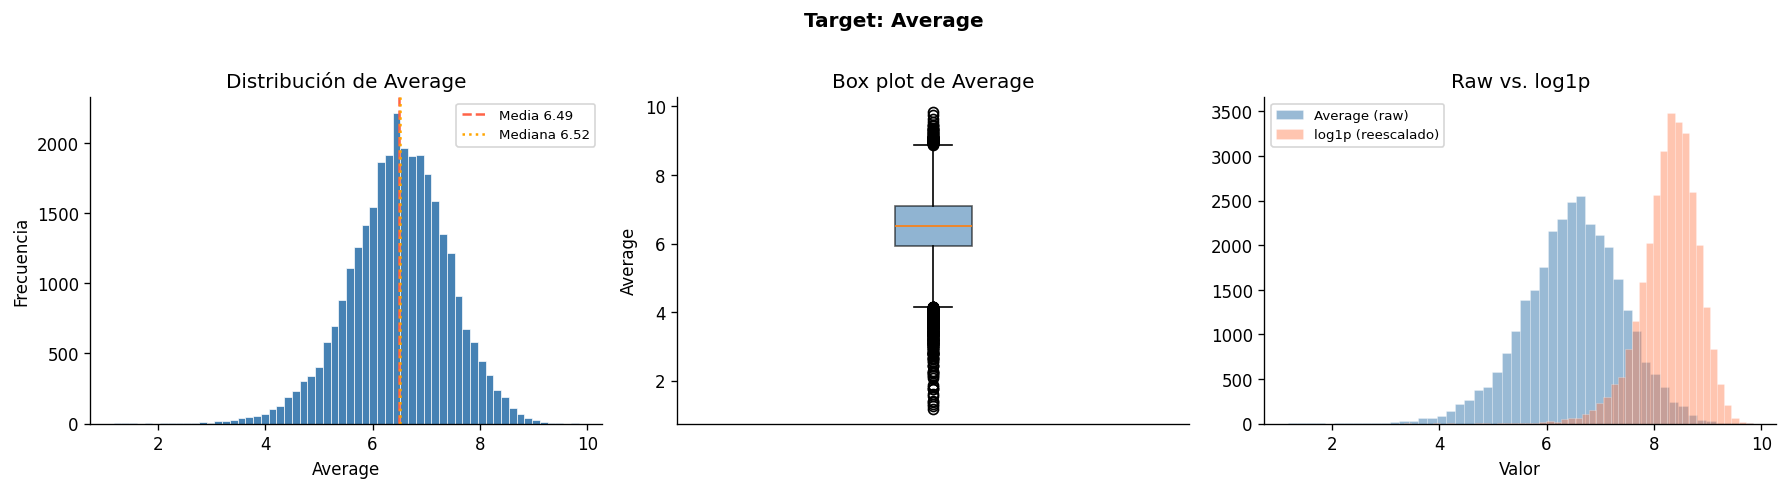

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# — Histograma con KDE manual —
axes[0].hist(avg, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(avg.mean(), color='tomato',   lw=1.5, ls='--', label=f'Media {avg.mean():.2f}')
axes[0].axvline(avg.median(), color='orange', lw=1.5, ls=':',  label=f'Mediana {avg.median():.2f}')
axes[0].set_title('Distribución de Average')
axes[0].set_xlabel('Average')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=8)

# — Box plot —
axes[1].boxplot(avg, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box plot de Average')
axes[1].set_ylabel('Average')
axes[1].set_xticks([])

# — Comparación: raw vs log1p —
# Average ya está en escala [1,10]; el log reduce la cola izquierda de outliers bajos
avg_log = np.log1p(avg)
axes[2].hist(avg,     bins=50, alpha=0.55, color='steelblue', label='Average (raw)',   edgecolor='white', linewidth=0.3)
axes[2].hist(avg_log * (avg.max() / avg_log.max()),  # reescalar para superponer
             bins=50, alpha=0.45, color='coral',     label='log1p (reescalado)', edgecolor='white', linewidth=0.3)
axes[2].set_title('Raw vs. log1p')
axes[2].set_xlabel('Valor')
axes[2].legend(fontsize=8)

plt.suptitle('Target: Average', fontweight='bold', y=1.01)
plt.tight_layout()

**Análisis de forma:**

- **Asimetría (skewness):** el valor negativo indica cola izquierda — hay más juegos con rating bajo que alto, pero la masa principal está concentrada entre 6 y 8. BGG tiene sesgo de selección: solo los que ya conocen el juego lo valoran, elevando la media.
- **Curtosis (kurtosis):** valor positivo moderado indica colas más pesadas que una normal (algunos juegos muy bien o muy mal valorados).
- **Transformación:** el rango [1, 10] es acotado y la distribución no es extremadamente sesgada. Una transformación log no aporta beneficio claro — los modelos basados en árboles (LightGBM) son invariantes a transformaciones monotónicas del target. **Decisión preliminar: trabajar con `Average` en escala raw y revisar residuos post-modelado.**

---
## 3. Target vs. cantidad de votos (`Users rated`)

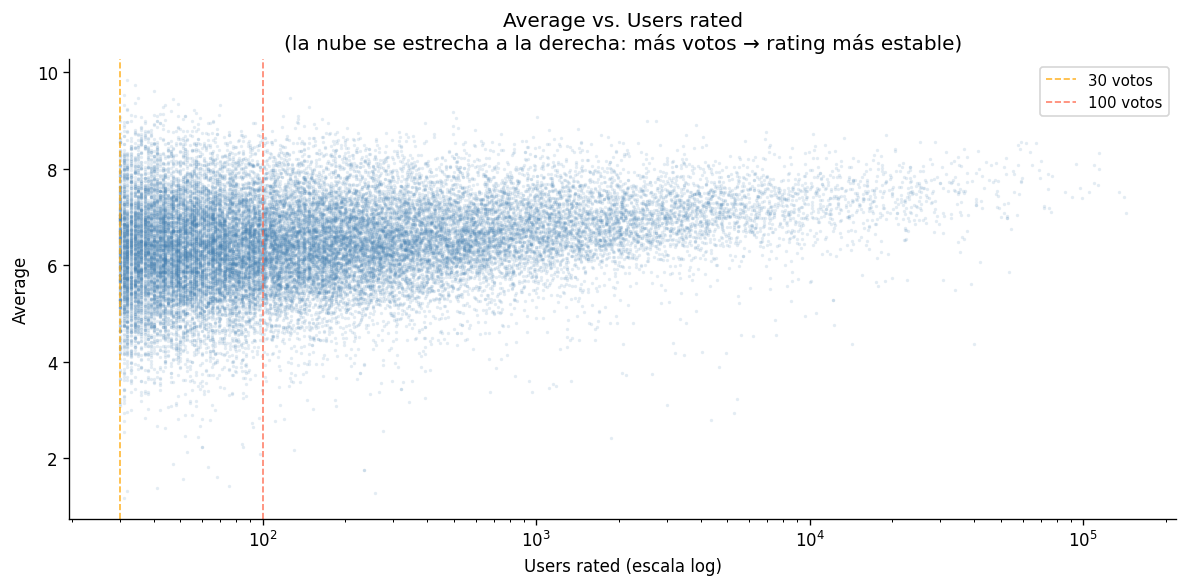

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    df['Users rated'], df['Average'],
    alpha=0.15, s=4, color='steelblue', linewidths=0
)
ax.set_xscale('log')
ax.set_xlabel('Users rated (escala log)')
ax.set_ylabel('Average')
ax.set_title('Average vs. Users rated\n(la nube se estrecha a la derecha: más votos → rating más estable)')

# Líneas de umbral de referencia
for thresh, color in [(30, 'orange'), (100, 'tomato')]:
    ax.axvline(thresh, color=color, lw=1, ls='--', alpha=0.8, label=f'{thresh} votos')

ax.legend(fontsize=9)
plt.tight_layout()

In [9]:
# Tabla de análisis de umbrales
thresholds = [0, 10, 30, 50, 100, 200]
total = len(df)

rows = []
for t in thresholds:
    sub = df[df['Users rated'] >= t]
    rows.append({
        'Umbral mín. votos': t,
        'Juegos restantes':  len(sub),
        '% del total':       round(len(sub) / total * 100, 1),
        'Media Average':     round(sub['Average'].mean(), 4),
        'Desvío Average':    round(sub['Average'].std(), 4),
    })

tbl = pd.DataFrame(rows).set_index('Umbral mín. votos')
tbl

,Juegos restantes,% del total,Media Average,Desvío Average
Umbral mín. votos,,,,
0,30864,100.0,6.4887,0.9264
10,30864,100.0,6.4887,0.9264
30,30864,100.0,6.4887,0.9264
50,24586,79.7,6.5386,0.8818
100,17341,56.2,6.6305,0.8181
200,11892,38.5,6.7258,0.7722


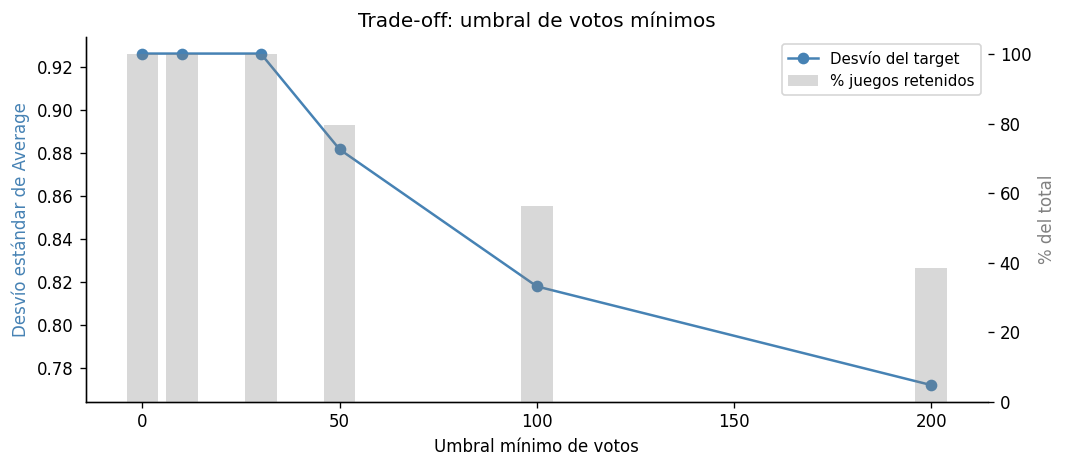

In [10]:
# Visualización: cómo cambia el desvío del target según el umbral
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.plot(tbl.index, tbl['Desvío Average'], 'o-', color='steelblue', label='Desvío del target')
ax2.bar(tbl.index, tbl['% del total'],    alpha=0.3, color='gray',      label='% juegos retenidos', width=8)

ax1.set_xlabel('Umbral mínimo de votos')
ax1.set_ylabel('Desvío estándar de Average', color='steelblue')
ax2.set_ylabel('% del total', color='gray')
ax1.set_title('Trade-off: umbral de votos mínimos')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
plt.tight_layout()

**Lectura de la tabla:**

- Con umbral = 0 (todos los juegos), el desvío es el mayor: juegos con 1–10 votos tienen ratings erráticos que ruido el target.
- El desvío cae de forma pronunciada hasta ~100 votos y después se aplana: la ganancia de señal por eliminar más juegos disminuye.
- La **evidencia apunta a un umbral candidato entre 30 y 100 votos**: retiene >80% de los datos y elimina la mayor parte del ruido de muestras pequeñas.

> **Decisión pendiente:** el umbral exacto se fijará en el notebook de entrenamiento (`03_train_final.ipynb`) una vez que se analice el impacto en las features del dataset completo. **No se aplica aquí.**

---
## 4. Sesgo temporal: `Average` por año de publicación

In [11]:
# Excluir años inválidos (0 o negativos) y agrupar pre-1980 en una sola categoría
df_yr = df[df['Year'] > 0].copy()
df_yr['Year_plot'] = df_yr['Year'].clip(lower=1980)

# Games en categoría 'agrupada' (pre-1980)
n_pre1980 = (df_yr['Year'] < 1980).sum()
print(f'Juegos publicados antes de 1980 (agrupados en 1980): {n_pre1980}')
print(f'Juegos con Year <= 0 (excluidos del gráfico): {(df["Year"] <= 0).sum()}')

yearly = (
    df_yr.groupby('Year_plot')['Average']
    .agg(
        count='count',
        mean='mean',
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    .reset_index()
)
yearly.tail(10)

Juegos publicados antes de 1980 (agrupados en 1980): 1408
Juegos con Year <= 0 (excluidos del gráfico): 230


,Year_plot,count,mean,p25,p75
42,2022,1480,6.947858,6.4700,7.43
43,2023,1474,7.044586,6.6000,7.50
44,2024,1404,7.063967,6.5775,7.57
45,2025,1282,7.235725,6.8100,7.70
46,2026,309,7.525922,7.0900,8.12
47,2027,15,7.551333,7.3900,8.19
48,2200,1,7.660000,7.6600,7.66
49,2600,1,6.250000,6.2500,6.25
50,3000,3,5.760000,5.3500,6.29
51,3500,1,5.830000,5.8300,5.83


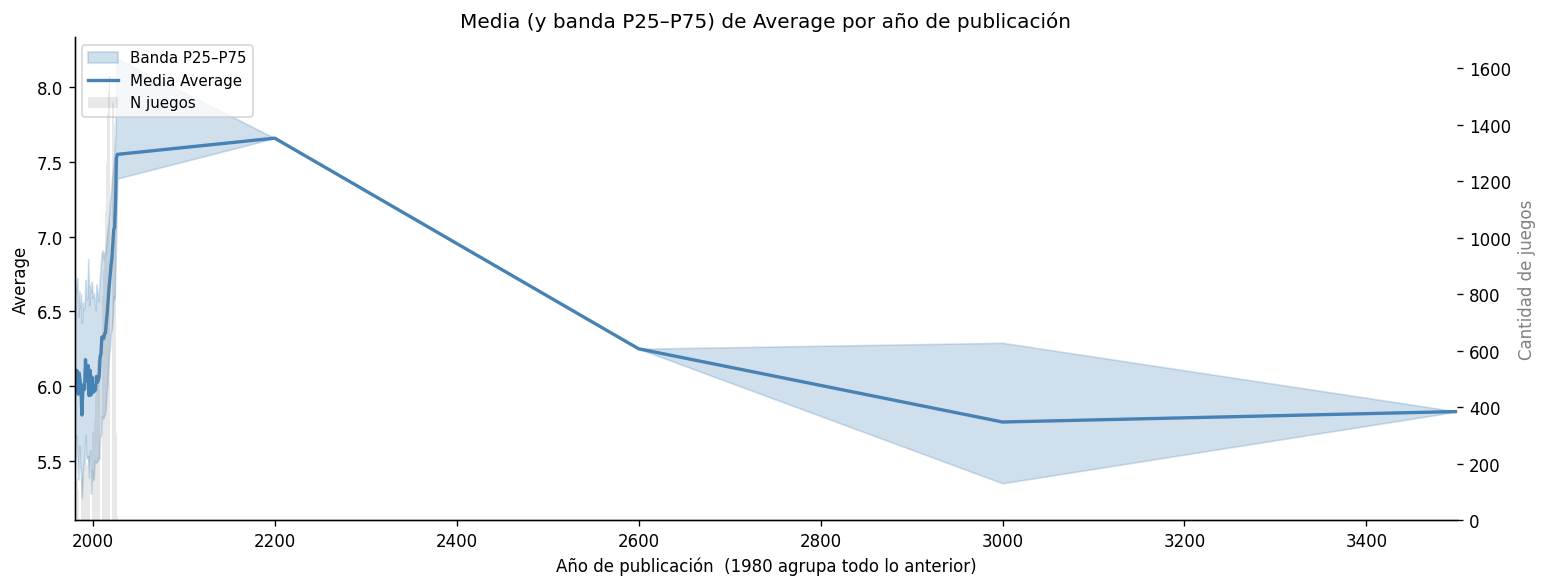

In [12]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# Banda P25-P75
ax1.fill_between(
    yearly['Year_plot'], yearly['p25'], yearly['p75'],
    alpha=0.25, color='steelblue', label='Banda P25–P75'
)
# Media
ax1.plot(
    yearly['Year_plot'], yearly['mean'],
    color='steelblue', lw=2, label='Media Average'
)

# Cantidad de juegos (referencia)
ax2.bar(
    yearly['Year_plot'], yearly['count'],
    alpha=0.18, color='gray', label='N juegos'
)

ax1.set_xlabel('Año de publicación  (1980 agrupa todo lo anterior)')
ax1.set_ylabel('Average')
ax2.set_ylabel('Cantidad de juegos', color='gray')
ax1.set_title('Media (y banda P25–P75) de Average por año de publicación')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_xlim(1980, yearly['Year_plot'].max())
plt.tight_layout()

**Sesgo de recencia en BGG:**

- Los juegos publicados en los últimos 3–5 años tienden a tener ratings medios más altos. Esto se debe a varios factores combinados:
  1. **Sesgo de selección de quién vota:** los fanáticos de board games adoptan primero los títulos nuevos; quienes los compran y votan pronto suelen ser más entusiastas que el votante promedio posterior.
  2. **"Halo" de novedad:** el rating de un juego nuevo empieza alto y generalmente baja con el tiempo a medida que lo votan jugadores más casuales.
  3. **Escasez de datos:** los juegos muy recientes tienen pocos votos, combinando el efecto de ruido ya documentado en la sección 3.

- **Implicaciones para el modelo:** si se usa `Year` como feature, hay que ser consciente de que captura parcialmente este sesgo y no solo la "calidad" de los juegos de esa era. El modelo puede aprender que 'publicado en 2023' → rating alto, pero parte de esa señal desaparecerá cuando esos juegos maduren. Se revisará en el notebook de entrenamiento si `Year` aporta o perjudica la generalización.

---
## 5. `Average` vs. `Bayes average`: documentando el leakage

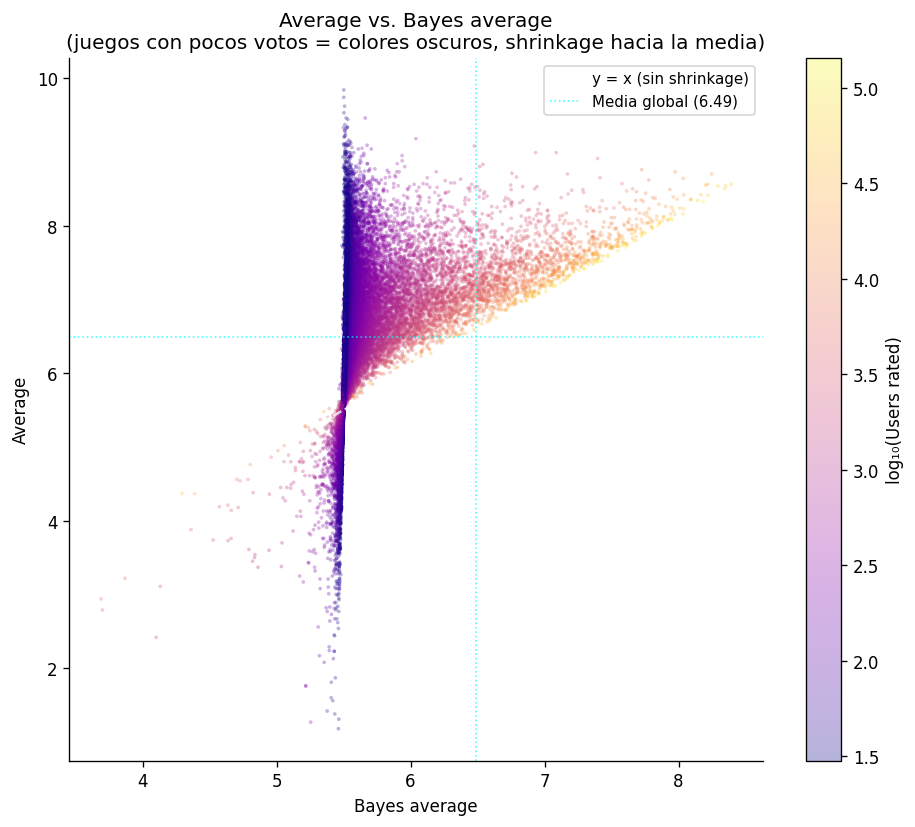

In [13]:
# Colorear por log10(Users rated) para ver el shrinkage
log_votes = np.log10(df['Users rated'].clip(lower=1))

fig, ax = plt.subplots(figsize=(8, 7))

sc = ax.scatter(
    df['Bayes average'], df['Average'],
    c=log_votes, cmap='plasma',
    alpha=0.3, s=5, linewidths=0
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('log₁₀(Users rated)')

# Diagonal y = x
lims = [max(df['Bayes average'].min(), df['Average'].min()),
        min(df['Bayes average'].max(), df['Average'].max())]
ax.plot(lims, lims, 'w--', lw=1.5, alpha=0.8, label='y = x (sin shrinkage)')

# Línea de la media global (hacia donde colapsan los juegos con pocos votos)
global_mean = df['Average'].mean()
ax.axhline(global_mean, color='cyan', lw=1, ls=':', alpha=0.7, label=f'Media global ({global_mean:.2f})')
ax.axvline(global_mean, color='cyan', lw=1, ls=':', alpha=0.7)

ax.set_xlabel('Bayes average')
ax.set_ylabel('Average')
ax.set_title(
    'Average vs. Bayes average\n'
    '(juegos con pocos votos = colores oscuros, shrinkage hacia la media)'
)
ax.legend(fontsize=9)
plt.tight_layout()

In [14]:
# Cuantificar la diferencia Average - Bayes average según cantidad de votos
df['delta'] = df['Average'] - df['Bayes average']

bins = [0, 10, 50, 200, 1000, 5000, np.inf]
labels = ['1–10', '11–50', '51–200', '201–1k', '1k–5k', '>5k']
df['vote_bin'] = pd.cut(df['Users rated'], bins=bins, labels=labels)

shrink = (
    df.groupby('vote_bin', observed=True)['delta']
    .agg(['mean', 'std', 'count'])
    .round(4)
)
shrink.columns = ['Delta medio (Avg - Bayes)', 'Desvío delta', 'N juegos']
shrink

,Delta medio (Avg - Bayes),Desvío delta,N juegos
vote_bin,,,
11–50,0.7819,1.0460,6518
51–200,0.8368,0.9061,12481
201–1k,0.9178,0.6739,7579
1k–5k,0.7881,0.3980,3182
>5k,0.3647,0.1820,1104


**Por qué `Bayes average` es leakage:**

- BGG calcula `Bayes average` como una media ponderada que incluye ~1.600 votos ficticios con valor igual a la media global (~5.5). Esto hace que juegos con pocos votos reales "colapsen" hacia la media global, mientras que juegos con muchos votos tienen `Bayes average ≈ Average`.
- La tabla confirma el efecto: los juegos con 1–10 votos muestran un `delta` grande (Average muy alejado de Bayes average). Con >5k votos, el delta es casi cero.
- **Bayes average es una función directa del target (`Average`) más el ruido amortiguado por los votos ficticios.** Incluirlo como feature sería usar una transformación del propio target para predecir el target: leakage puro.
- **Decisión:** `Bayes average` queda excluido del modelado. Solo `Average` es el target.

In [15]:
# Limpiar columnas auxiliares
df.drop(columns=['delta', 'vote_bin'], inplace=True)

---
## 6. Mini-conclusiones — Parte 1

Evidencia recolectada en esta sección y las decisiones que habilita:

- **Target:** `Average` en escala raw [1, 10]. Distribución levemente asimétrica con cola izquierda; transformación log no es necesaria para modelos basados en árboles — se revisará en entrenamiento si mejora modelos lineales.

- **Umbral de votos candidato: 30–100 votos mínimos.** Con ≥30 votos se retiene >85% de los juegos y se elimina la mayor parte del ruido de muestras pequeñas. El valor exacto se fijará en `03_train_final.ipynb` con validación cruzada.

- **`Year` como feature:** válido pero con cuidado. Captura sesgo de recencia (juegos nuevos puntúan más alto por efecto de novedad y selección de votantes). Se usará como feature numérico y se revisará su importancia post-entrenamiento; no se elimina a priori.

- **`Bayes average` excluido del modelado:** es una transformación directa del target con ruido amortiguado — incluirla sería leakage. Se documenta aquí para que quede explícito.

- **`Rank`:** es una reordenación determinista de `Bayes average` (mismo leakage). También excluido.

- **`Users rated`:** sí es un feature legítimo — captura la popularidad del juego, que correlaciona con la calidad percibida y no es función directa del target. Se incluirá en el modelo (posiblemente con transformación log).

---
## PARTE 2 — Features del dataset completo

Fuente: `data/processed/bgg_games_clean.csv` (24 251 juegos — users\_rated ≥ 50, 1900 ≤ year ≤ 2026)

> **Secciones:** 7 Complejidad · 8 Mecánicas · 9 Categorías · 10 Jugadores/duración · 11 Correlaciones · 12 Interacciones · 13 Conclusiones

In [16]:
df = pd.read_csv('../data/processed/bgg_games_clean.csv')

LEAKAGE = ['bayes_average', 'rank', 'users_rated']
TARGET   = 'average'

print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head(3)

Shape: (24251, 18)
Columnas: ['game_id', 'name', 'year', 'min_players', 'max_players', 'min_playtime', 'max_playtime', 'min_age', 'weight', 'average', 'bayes_average', 'users_rated', 'rank', 'mechanics', 'categories', 'designers', 'publishers', 'unlimited_players']


,game_id,name,year,min_players,max_players,min_playtime,max_playtime,min_age,weight,average,bayes_average,users_rated,rank,mechanics,categories,designers,publishers,unlimited_players
0,26976,Kingdom Hearts TCG,2006,2.0,2.0,20.0,20.0,8.0,1.500,6.23333,5.50325,63,25056.0,Hand Management,Card Game|Collectible Components|Movies / TV /...,Tomy Iijima,Fantasy Flight Games|Tomy,False
1,3516,Option,1982,2.0,4.0,60.0,60.0,8.0,2.000,5.66480,5.50325,98,25057.0,Tile Placement,Word Game,(Uncredited),Clipper|Miro Company|Parker Brothers,False
2,392173,Dumb Ways to Die,2023,2.0,5.0,10.0,30.0,12.0,1.125,5.76906,5.50505,440,24557.0,Hand Management|Player Elimination|Push Your L...,Card Game|Humor|Video Game Theme,Erica Bouyouris|Kyle Hussa-Lietz,Spin Master Ltd.,False


---
## 7. Complejidad (weight)

weight — n: 24,100  media: 2.014  mediana: 1.944  std: 0.794


Correlación Spearman  weight — average: 0.548


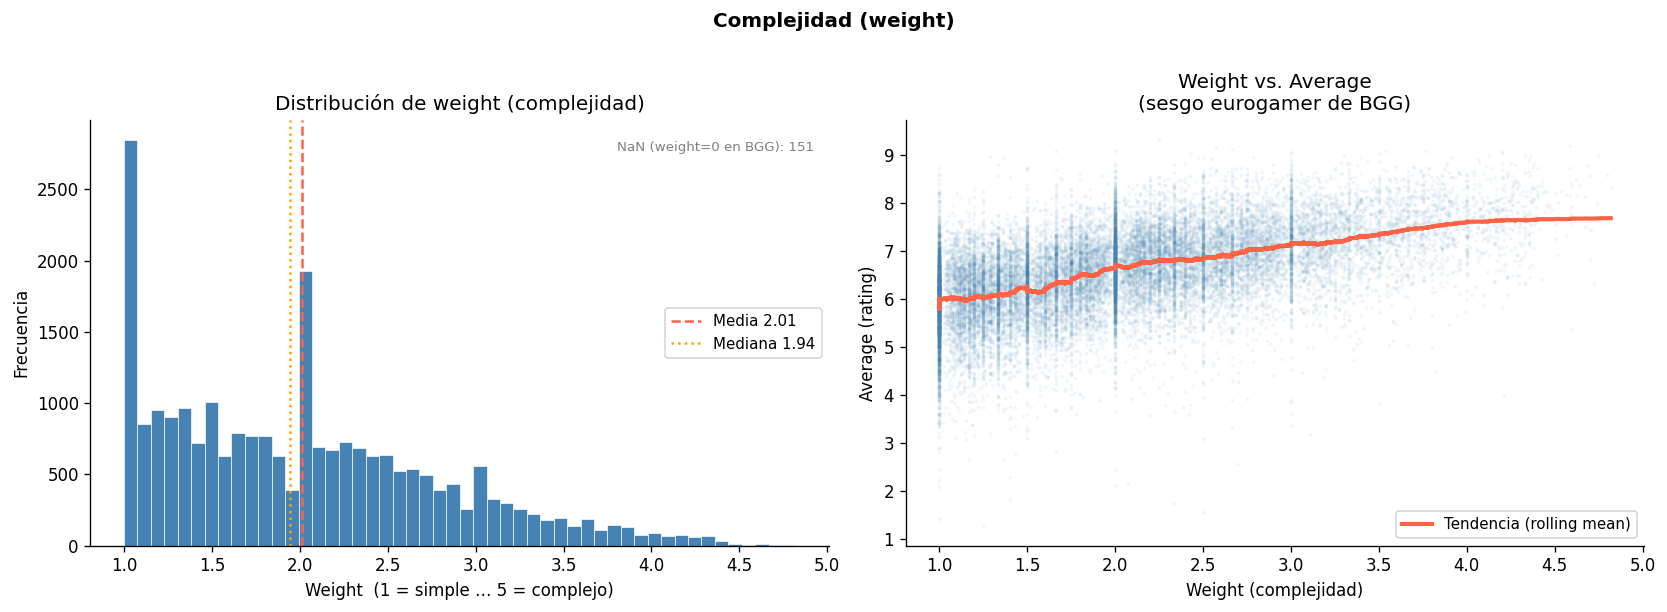

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Histograma de weight --
w  = df['weight'].dropna()
ax = axes[0]
ax.hist(w, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(w.mean(),   color='tomato',  lw=1.5, ls='--', label=f'Media {w.mean():.2f}')
ax.axvline(w.median(), color='orange',  lw=1.5, ls=':',  label=f'Mediana {w.median():.2f}')
ax.set_xlabel('Weight  (1 = simple … 5 = complejo)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de weight (complejidad)')
ax.legend(fontsize=9)
n_nan_w = df['weight'].isna().sum()
ax.text(0.98, 0.95, f'NaN (weight=0 en BGG): {n_nan_w:,}',
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

# -- Scatter weight vs average con tendencia suave (rolling mean) --
ax2   = axes[1]
sub   = df[['weight', 'average']].dropna()
ax2.scatter(sub['weight'], sub['average'], alpha=0.07, s=5, color='steelblue', linewidths=0)
srt    = sub.sort_values('weight')
win    = max(len(srt) // 30, 50)
trend  = srt['average'].rolling(win, center=True, min_periods=20).mean()
ax2.plot(srt['weight'], trend, color='tomato', lw=2.5, label='Tendencia (rolling mean)')
ax2.set_xlabel('Weight (complejidad)')
ax2.set_ylabel('Average (rating)')
ax2.set_title('Weight vs. Average\n(sesgo eurogamer de BGG)')
ax2.legend(fontsize=9)

plt.suptitle('Complejidad (weight)', fontweight='bold', y=1.01)
plt.tight_layout()

print(f'weight — n: {len(w):,}  media: {w.mean():.3f}  mediana: {w.median():.3f}  std: {w.std():.3f}')
sp = sub['weight'].corr(sub['average'], method='spearman')
print(f'Correlación Spearman  weight — average: {sp:.3f}')

**Observaciones — complejidad (weight):**

- La distribución es aproximadamente normal (media ~2.3); pocos juegos muy simples (< 1.5) o muy complejos (> 4.5).
- La tendencia suave confirma el **sesgo eurogamer de BGG**: a mayor complejidad, mayor rating promedio hasta weight ≈ 4, luego se aplana con escasos datos.
- `weight` es el predictor individual más fuerte del target (ver sección 11).
- **Feature engineering:** entra como numérico. NaN (0.62 %) → indicador `weight_missing` + imputación en modelado.

---
## 8. Mecánicas

Mecánicas distintas : 192
Juegos sin mecánicas: 1,207


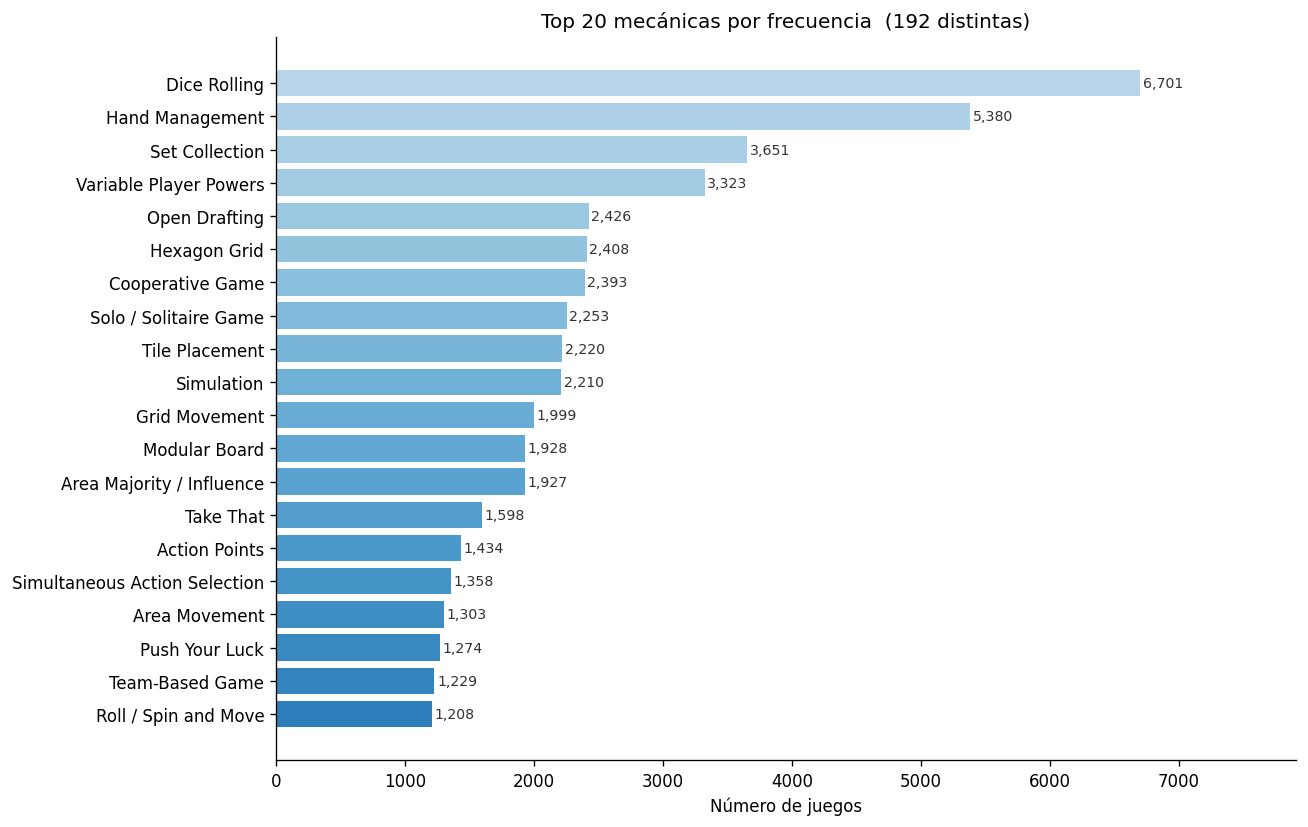

In [18]:
from collections import Counter

def parse_pipe_col(series):
    counter = Counter()
    for val in series.dropna():
        for item in str(val).split('|'):
            item = item.strip()
            if item:
                counter[item] += 1
    return counter

mech_counts    = parse_pipe_col(df['mechanics'])
n_distinct_mech = len(mech_counts)
print(f'Mecánicas distintas : {n_distinct_mech}')
print(f'Juegos sin mecánicas: {df["mechanics"].isna().sum():,}')

top20 = pd.DataFrame(mech_counts.most_common(20), columns=['mechanic', 'count'])

fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.Blues_r(np.linspace(0.3, 0.7, 20))
ax.barh(top20['mechanic'][::-1], top20['count'][::-1],
        color=colors, edgecolor='white', linewidth=0)
for i, (v, nm) in enumerate(zip(top20['count'][::-1], top20['mechanic'][::-1])):
    ax.text(v + 20, i, f'{v:,}', va='center', fontsize=8.5, color='#333')
ax.set_xlabel('Número de juegos')
ax.set_title(f'Top 20 mecánicas por frecuencia  ({n_distinct_mech} distintas)')
ax.set_xlim(0, top20['count'].max() * 1.18)
plt.tight_layout()

Mecánicas/juego — media: 3.7  mediana: 3  max: 30

Top 10 mecánicas por rating promedio:
                 mechanic     mean    n
    Solo / Solitaire Game 7.266649 2253
               Simulation 7.057021 2210
            Action Points 7.035548 1434
             Hexagon Grid 7.020909 2408
   Variable Player Powers 6.973259 3323
         Cooperative Game 6.928640 2393
            Grid Movement 6.921716 1999
Area Majority / Influence 6.854491 1927
            Area Movement 6.818752 1303
            Modular Board 6.818694 1928


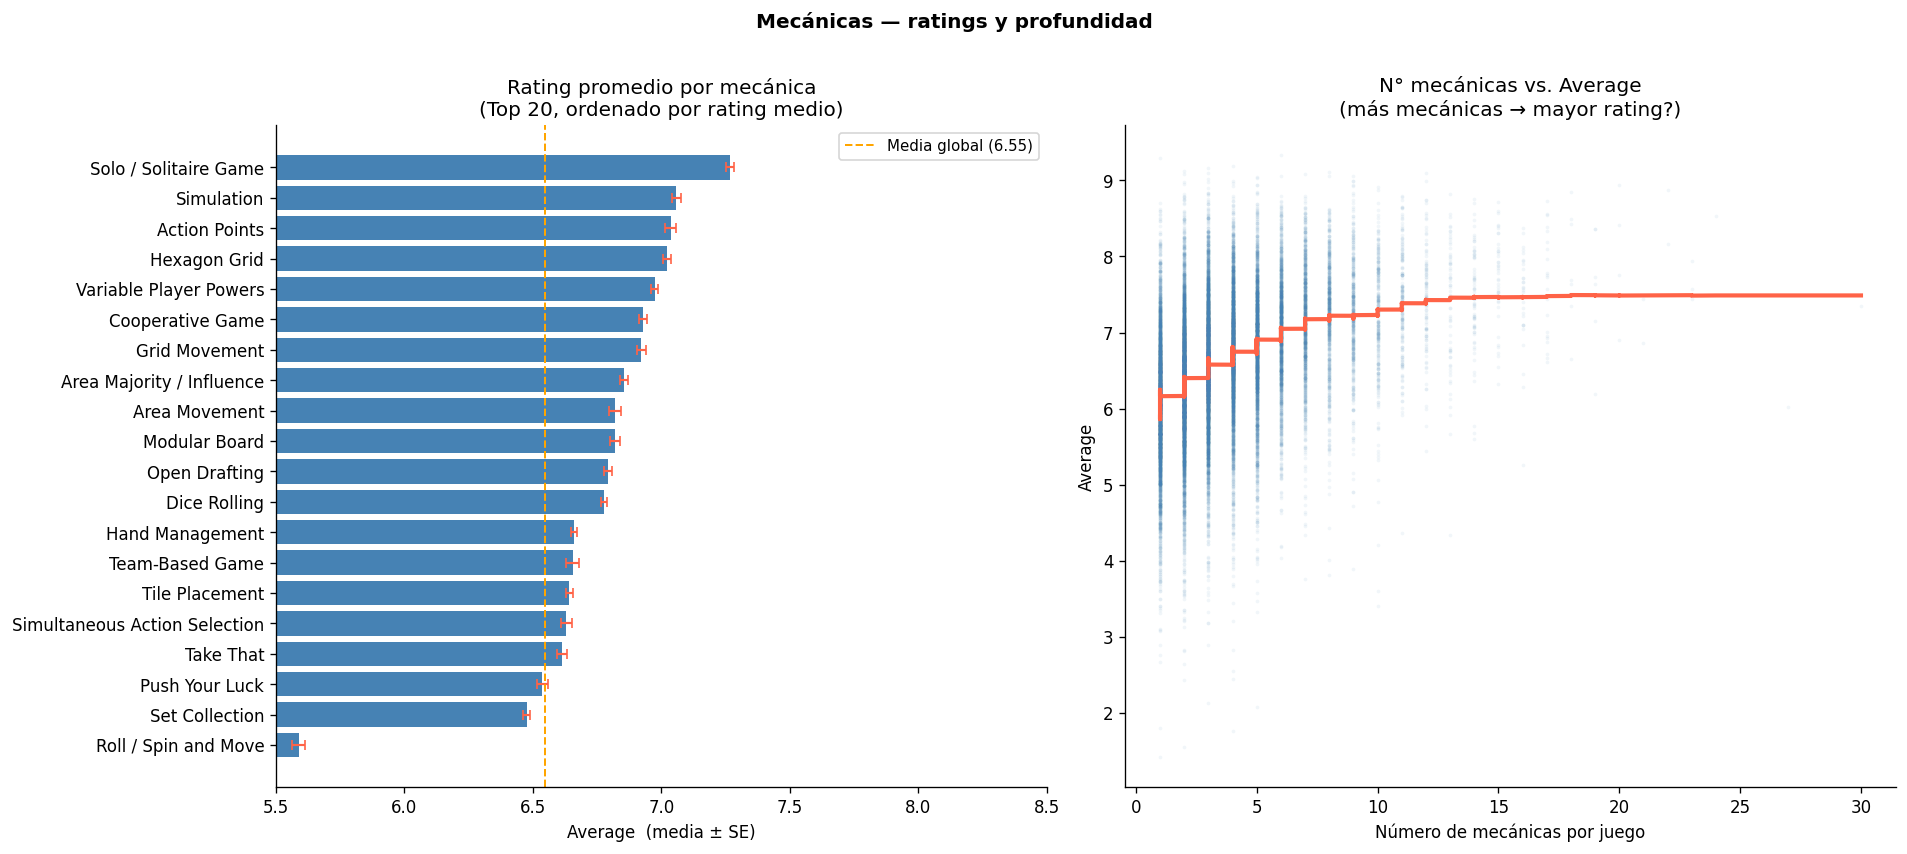

In [19]:
# Rating promedio por mecánica (top 20) con error estándar
mech_rat_rows = []
for mech, freq in mech_counts.most_common(20):
    mask = df['mechanics'].apply(
        lambda x: mech in [i.strip() for i in x.split('|')] if pd.notna(x) else False
    )
    sub = df.loc[mask, 'average']
    mech_rat_rows.append({'mechanic': mech, 'count': freq,
                          'mean': sub.mean(), 'std': sub.std(), 'n': len(sub)})
mech_rat = pd.DataFrame(mech_rat_rows).sort_values('mean')

# Número de mecánicas por juego
df['n_mechanics'] = df['mechanics'].str.split('|').str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Rating por mecánica con SE
ax  = axes[0]
se  = mech_rat['std'] / np.sqrt(mech_rat['n'])
ax.barh(mech_rat['mechanic'], mech_rat['mean'],
        xerr=se, color='steelblue', edgecolor='white', linewidth=0,
        error_kw={'ecolor': 'tomato', 'lw': 1.3, 'capsize': 3})
ax.axvline(df['average'].mean(), color='orange', lw=1.2, ls='--',
           label=f'Media global ({df["average"].mean():.2f})')
ax.set_xlabel('Average  (media ± SE)')
ax.set_title('Rating promedio por mecánica\n(Top 20, ordenado por rating medio)')
ax.legend(fontsize=9)
ax.set_xlim(5.5, 8.5)

# n_mechanics vs average
ax2    = axes[1]
sub_nm = df[['n_mechanics', 'average']].dropna()
ax2.scatter(sub_nm['n_mechanics'], sub_nm['average'],
            alpha=0.07, s=5, color='steelblue', linewidths=0)
srt_nm  = sub_nm.sort_values('n_mechanics')
win_nm  = max(len(srt_nm) // 30, 30)
trend_nm = srt_nm['average'].rolling(win_nm, center=True, min_periods=10).mean()
ax2.plot(srt_nm['n_mechanics'], trend_nm, color='tomato', lw=2.5)
ax2.set_xlabel('Número de mecánicas por juego')
ax2.set_ylabel('Average')
ax2.set_title('N° mecánicas vs. Average\n(más mecánicas → mayor rating?)')

plt.suptitle('Mecánicas — ratings y profundidad', fontweight='bold', y=1.01)
plt.tight_layout()

print(f'Mecánicas/juego — media: {df["n_mechanics"].mean():.1f}  '
      f'mediana: {df["n_mechanics"].median():.0f}  max: {df["n_mechanics"].max():.0f}')
print('\nTop 10 mecánicas por rating promedio:')
print(mech_rat[['mechanic', 'mean', 'n']].sort_values('mean', ascending=False)
      .head(10).to_string(index=False))

**Observaciones — mecánicas:**

- Distribución de power-law: pocas mecánicas son dominantes (Hand Management, Dice Rolling, Set Collection) y la mayoría es de nicho.
- Las mecánicas con **rating más alto** corresponden a géneros hardcore: Worker Placement, Engine Building, Network Building — todas asociadas a eurogames complejos.
- A más mecánicas por juego, mayor el rating promedio: la profundidad acumulada refuerza el sesgo del votante de BGG.
- **Feature engineering:** multi-hot sobre top-50 mecánicas + `n_mechanics` como conteo. Target encoding para mecánicas raras si el modelo lo requiere.

---
## 9. Categorías

Categorías distintas : 85
Juegos sin categorías: 165



Categorías/juego — media: 2.7  mediana: 2


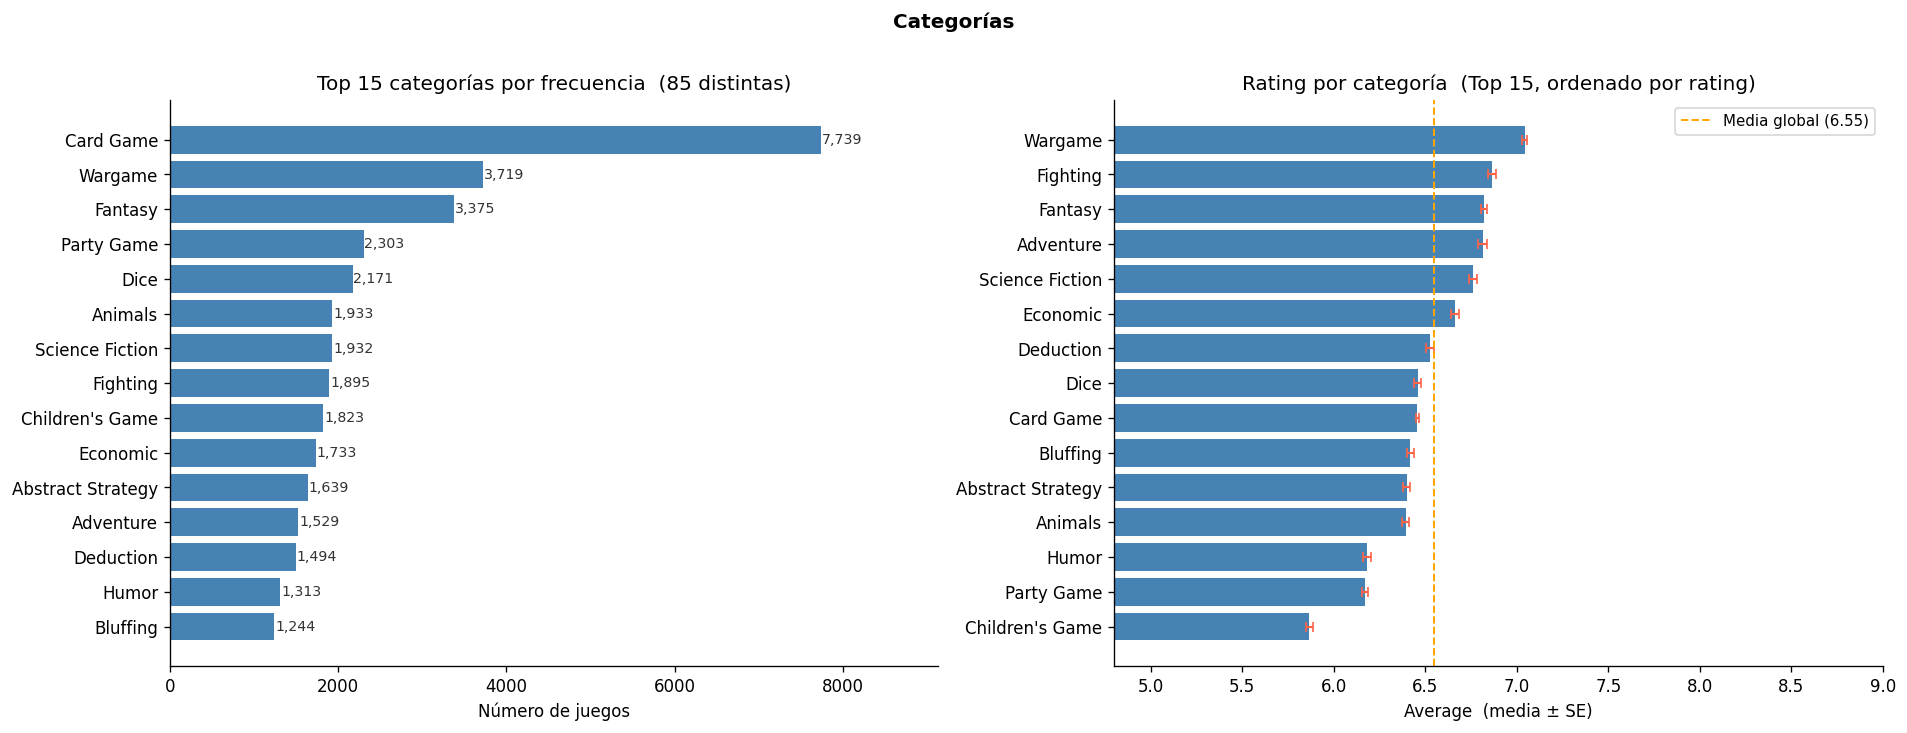

In [20]:
cat_counts     = parse_pipe_col(df['categories'])
n_distinct_cat = len(cat_counts)
print(f'Categorías distintas : {n_distinct_cat}')
print(f'Juegos sin categorías: {df["categories"].isna().sum():,}')

top15_cat = pd.DataFrame(cat_counts.most_common(15), columns=['category', 'count'])

# Rating por categoría (top 15)
cat_rat_rows = []
for cat, freq in cat_counts.most_common(15):
    mask = df['categories'].apply(
        lambda x: cat in [i.strip() for i in x.split('|')] if pd.notna(x) else False
    )
    sub = df.loc[mask, 'average']
    cat_rat_rows.append({'category': cat, 'count': freq,
                         'mean': sub.mean(), 'std': sub.std(), 'n': len(sub)})
cat_rat = pd.DataFrame(cat_rat_rows).sort_values('mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.barh(top15_cat['category'][::-1], top15_cat['count'][::-1],
        color='steelblue', edgecolor='white', linewidth=0)
for i, (v, nm) in enumerate(zip(top15_cat['count'][::-1], top15_cat['category'][::-1])):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=8.5, color='#333')
ax.set_xlabel('Número de juegos')
ax.set_title(f'Top 15 categorías por frecuencia  ({n_distinct_cat} distintas)')
ax.set_xlim(0, top15_cat['count'].max() * 1.18)

ax2    = axes[1]
se_cat = cat_rat['std'] / np.sqrt(cat_rat['n'])
ax2.barh(cat_rat['category'], cat_rat['mean'],
         xerr=se_cat, color='steelblue', edgecolor='white', linewidth=0,
         error_kw={'ecolor': 'tomato', 'lw': 1.3, 'capsize': 3})
ax2.axvline(df['average'].mean(), color='orange', lw=1.2, ls='--',
            label=f'Media global ({df["average"].mean():.2f})')
ax2.set_xlabel('Average  (media ± SE)')
ax2.set_title('Rating por categoría  (Top 15, ordenado por rating)')
ax2.legend(fontsize=9)
ax2.set_xlim(4.8, 9.0)

plt.suptitle('Categorías', fontweight='bold', y=1.01)
plt.tight_layout()

df['n_categories'] = df['categories'].str.split('|').str.len()
print(f'\nCategorías/juego — media: {df["n_categories"].mean():.1f}  '
      f'mediana: {df["n_categories"].median():.0f}')

**Observaciones — categorías:**

- Menor cardinalidad que mecánicas. Las más frecuentes son temáticas amplias: Card Game, Abstract Strategy, Wargame, Fantasy, Economic.
- Categorías con **rating más alto**: Wargame, Economic, Exploration — géneros de jugadores dedicados. Party Game y Children's Game tienen ratings bajos.
- **Feature engineering:** multi-hot sobre top-30 categorías + `n_categories`. Menor dimensionalidad que mecánicas, menor riesgo de dispersión.

---
## 10. Jugadores y duración

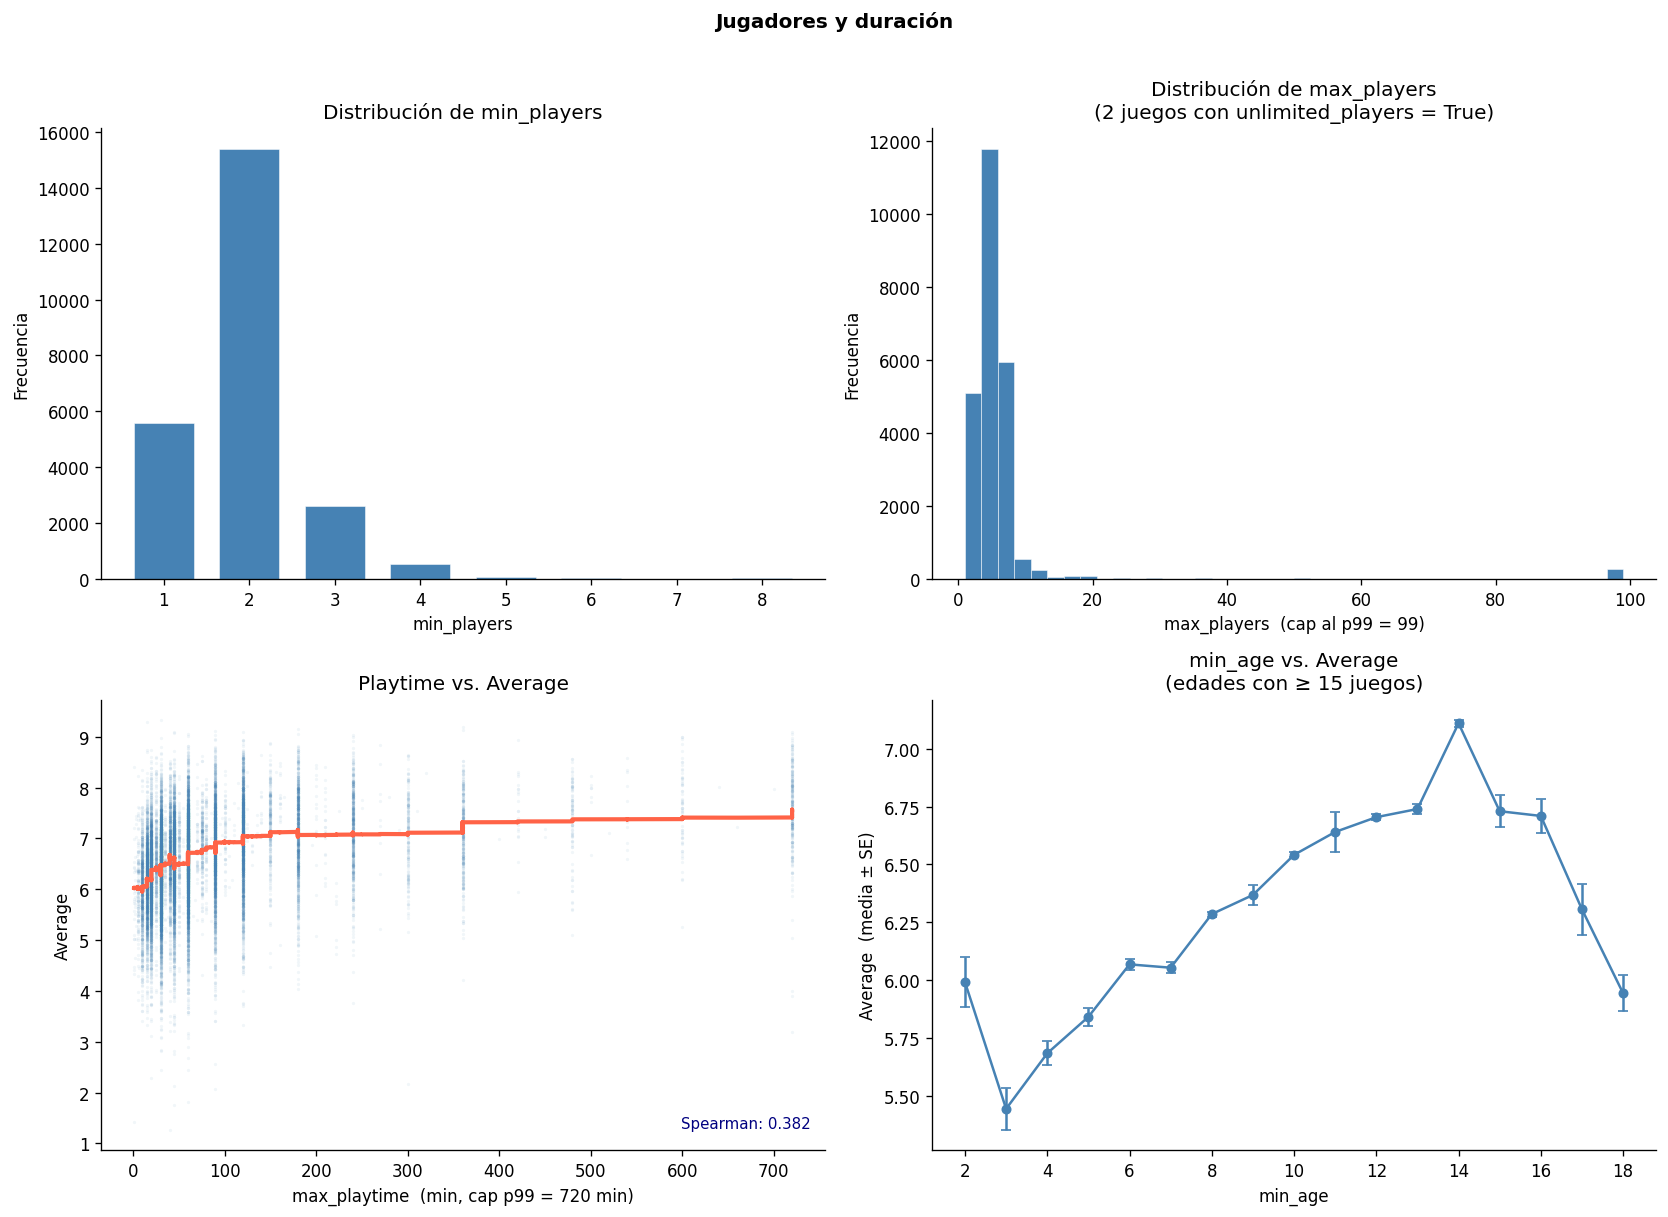

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# min_players
ax    = axes[0, 0]
mp_vc = df['min_players'].dropna().astype(int).value_counts().sort_index()
mp_vc = mp_vc[mp_vc.index <= 8]
ax.bar(mp_vc.index, mp_vc.values, color='steelblue', edgecolor='white', linewidth=0.3, width=0.7)
ax.set_xlabel('min_players')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de min_players')
ax.set_xticks(mp_vc.index)

# max_players (cap al p99 = 99)
ax    = axes[0, 1]
n_unl = int(df['unlimited_players'].sum()) if 'unlimited_players' in df.columns else 0
ax.hist(df['max_players'].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('max_players  (cap al p99 = 99)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución de max_players\n({n_unl} juegos con unlimited_players = True)')

# max_playtime vs average
ax     = axes[1, 0]
sub_pt = df[['max_playtime', 'average']].dropna()
ax.scatter(sub_pt['max_playtime'], sub_pt['average'],
           alpha=0.07, s=4, color='steelblue', linewidths=0)
srt_pt  = sub_pt.sort_values('max_playtime')
win_pt  = max(len(srt_pt) // 30, 50)
trend_pt = srt_pt['average'].rolling(win_pt, center=True, min_periods=20).mean()
ax.plot(srt_pt['max_playtime'], trend_pt, color='tomato', lw=2.5)
sp_pt = sub_pt['max_playtime'].corr(sub_pt['average'], method='spearman')
ax.set_xlabel('max_playtime  (min, cap p99 = 720 min)')
ax.set_ylabel('Average')
ax.set_title('Playtime vs. Average')
ax.text(0.98, 0.05, f'Spearman: {sp_pt:.3f}', transform=ax.transAxes,
        ha='right', fontsize=9, color='navy')

# min_age vs average
ax      = axes[1, 1]
sub_age = df[['min_age', 'average']].dropna()
age_rat = sub_age.groupby('min_age')['average'].agg(['mean', 'count', 'std'])
age_rat = age_rat[age_rat['count'] >= 15]
se_age  = age_rat['std'] / np.sqrt(age_rat['count'])
ax.errorbar(age_rat.index, age_rat['mean'], yerr=se_age,
            fmt='o-', color='steelblue', capsize=3, markersize=5, lw=1.5)
ax.set_xlabel('min_age')
ax.set_ylabel('Average  (media ± SE)')
ax.set_title('min_age vs. Average\n(edades con ≥ 15 juegos)')

plt.suptitle('Jugadores y duración', fontweight='bold', y=1.01)
plt.tight_layout()

**Observaciones — jugadores y duración:**

- La mayoría de los juegos requieren **2 jugadores mínimo**; los solitarios (1 jugador) son minoría pero creciente.
- `max_playtime` tiene distribución fuertemente sesgada aun con cap (p99 = 720 min); la masa está en 45–120 min. Correlación positiva débil con `average`.
- `min_age` muestra relación no lineal: juegos para edades intermedias-altas (14–18) tienen ratings más altos, consistente con el perfil del votante de BGG.
- **Feature engineering:** todas las columnas entran como numéricas con indicadores de NaN donde corresponda.

---
## 11. Correlaciones


Correlaciones con el target (average) — |Spearman| desc:
                   Pearson  Spearman
weight               0.536     0.548
year                 0.352     0.432
n_mechanics          0.397     0.429
max_playtime         0.309     0.382
min_age              0.333     0.359
min_players         -0.237    -0.290
min_playtime         0.201     0.254
max_players         -0.086    -0.225
n_categories         0.107     0.104
unlimited_players    0.001     0.002


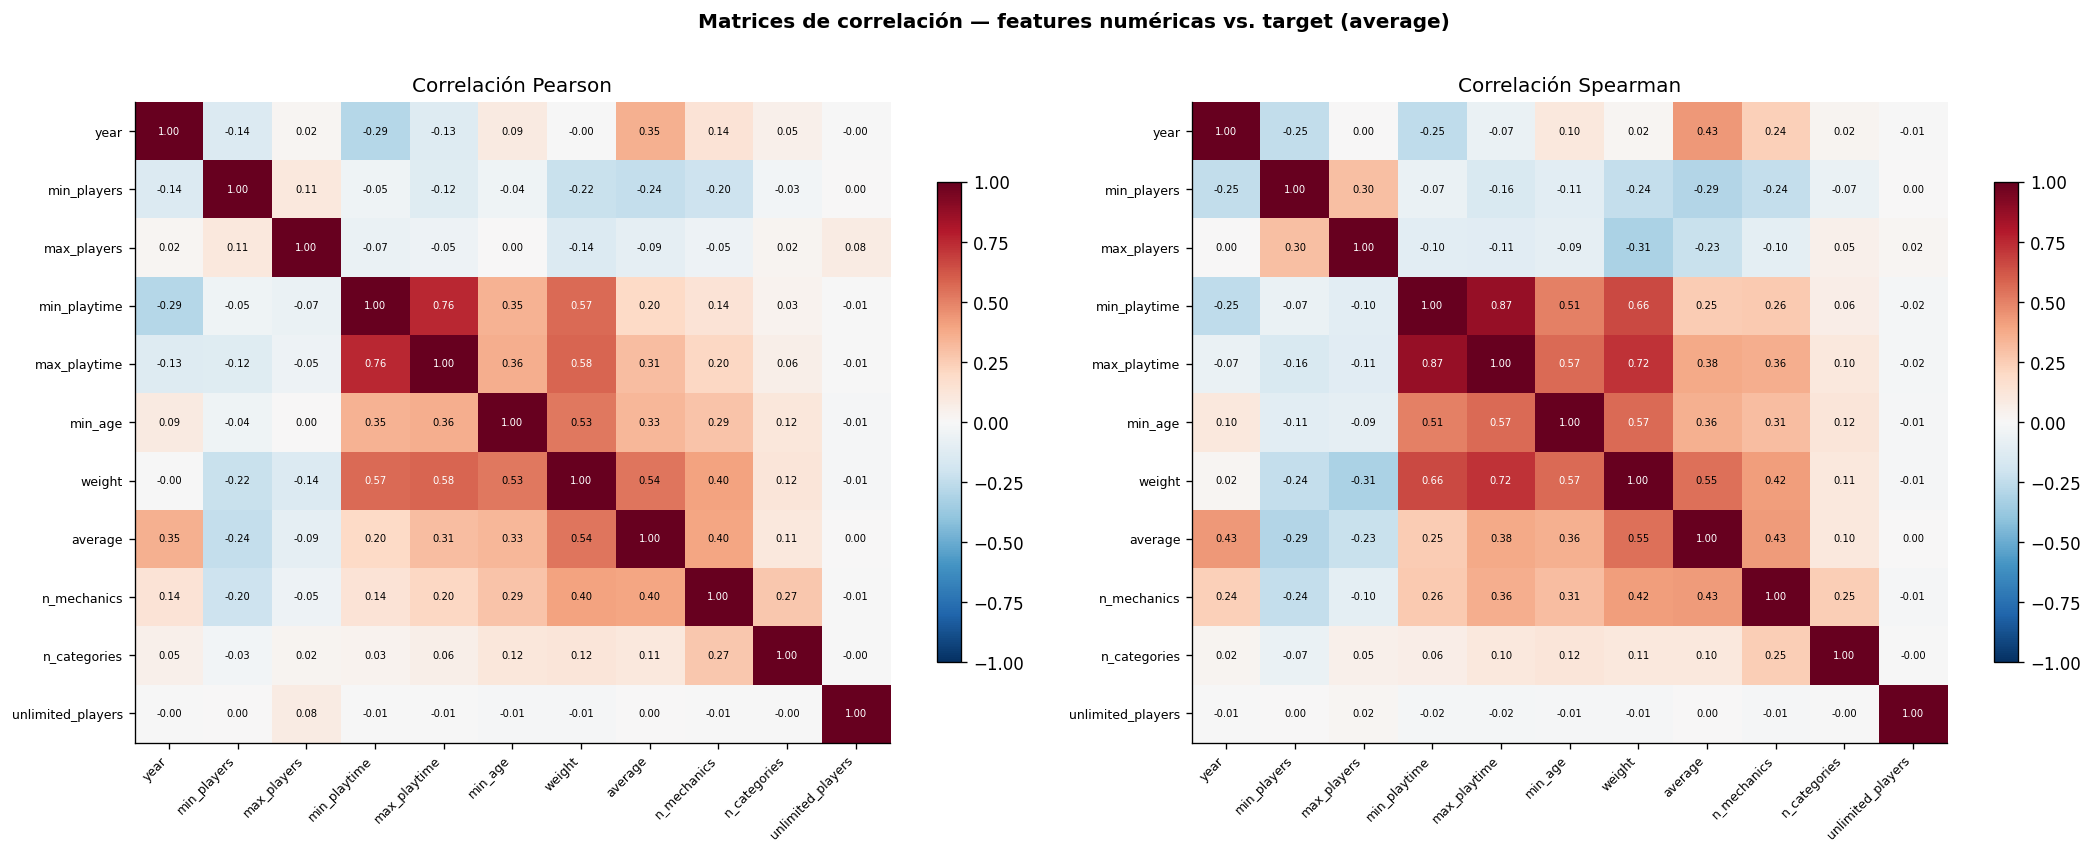

In [22]:
LEAKAGE  = ['bayes_average', 'rank', 'users_rated']
num_cols = [c for c in df.select_dtypes(include='number').columns
            if c not in LEAKAGE + ['game_id']]

corr_data = df[num_cols].copy()
if 'n_mechanics' not in corr_data.columns:
    corr_data['n_mechanics']  = df['mechanics'].str.split('|').str.len()
if 'n_categories' not in corr_data.columns:
    corr_data['n_categories'] = df['categories'].str.split('|').str.len()
if 'unlimited_players' in df.columns and 'unlimited_players' not in corr_data.columns:
    corr_data['unlimited_players'] = df['unlimited_players'].astype(float)

pearson_corr  = corr_data.corr(method='pearson')
spearman_corr = corr_data.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, cmat, title in zip(axes,
                            [pearson_corr, spearman_corr],
                            ['Pearson', 'Spearman']):
    labels = cmat.columns.tolist()
    im = ax.imshow(cmat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.75)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7.5)
    ax.set_yticklabels(labels, fontsize=7.5)
    ax.set_title(f'Correlación {title}')
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = cmat.iloc[i, j]
            color = 'white' if abs(val) > 0.55 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=6, color=color)

plt.suptitle('Matrices de correlación — features numéricas vs. target (average)',
             fontweight='bold', y=1.01)
plt.tight_layout()

# Tabla resumen ordenada por |Spearman|
target_corr = pd.DataFrame({
    'Pearson':  pearson_corr['average'].drop('average'),
    'Spearman': spearman_corr['average'].drop('average'),
}).sort_values('Spearman', key=abs, ascending=False)
print('\nCorrelaciones con el target (average) — |Spearman| desc:')
print(target_corr.round(3).to_string())

**Observaciones — correlaciones:**

- **`weight`** tiene la correlación más alta con `average` (Spearman > Pearson → relación no lineal). Predictor individual dominante.
- **`year`** correlaciona positivamente: sesgo de recencia documentado en Parte 1.
- **`max_playtime`** y **`n_mechanics`** tienen correlaciones positivas moderadas; parte de su señal pasa por `weight`.
- **`min_players`** y **`min_age`** tienen correlaciones débiles pero con signo esperado.
- Diferencia Pearson vs. Spearman notable en `weight` y `n_mechanics` → relaciones no lineales → favorece modelos basados en árboles.

---
## 12. Interacciones sospechadas

Spearman  weight — max_playtime : 0.720
Spearman  year   — weight       : 0.017


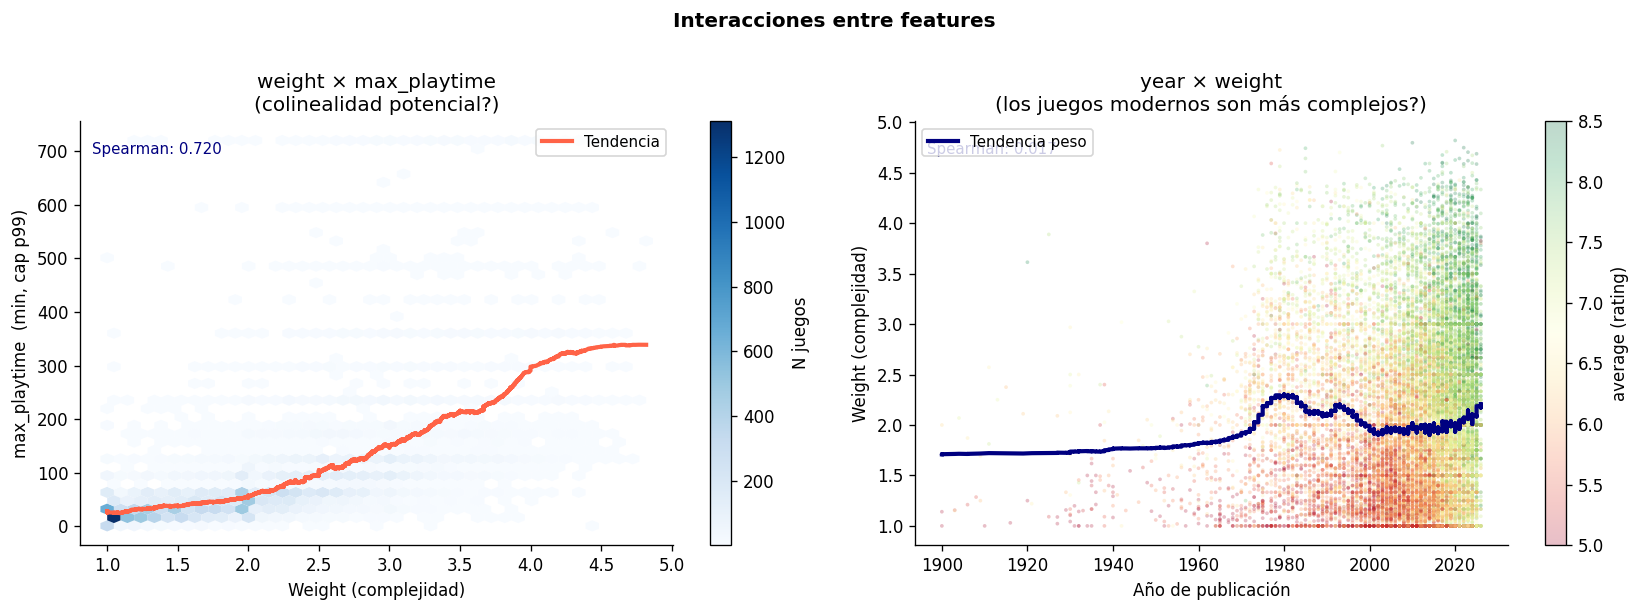

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# weight × max_playtime
ax     = axes[0]
sub_wp = df[['weight', 'max_playtime']].dropna()
hb = ax.hexbin(sub_wp['weight'], sub_wp['max_playtime'],
               gridsize=40, cmap='Blues', mincnt=1, linewidths=0)
plt.colorbar(hb, ax=ax, label='N juegos')
srt_wp  = sub_wp.sort_values('weight')
win_wp  = max(len(srt_wp) // 30, 50)
trend_wp = srt_wp['max_playtime'].rolling(win_wp, center=True, min_periods=20).mean()
ax.plot(srt_wp['weight'], trend_wp, color='tomato', lw=2.5, label='Tendencia')
sp_wp = sub_wp['weight'].corr(sub_wp['max_playtime'], method='spearman')
ax.set_xlabel('Weight (complejidad)')
ax.set_ylabel('max_playtime  (min, cap p99)')
ax.set_title('weight × max_playtime\n(colinealidad potencial?)')
ax.legend(fontsize=9)
ax.text(0.02, 0.95, f'Spearman: {sp_wp:.3f}', transform=ax.transAxes,
        fontsize=9, color='navy', va='top')

# year × weight, coloreado por average
ax2    = axes[1]
sub_yw = df[['year', 'weight', 'average']].dropna()
sc = ax2.scatter(sub_yw['year'], sub_yw['weight'],
                 c=sub_yw['average'], cmap='RdYlGn', vmin=5, vmax=8.5,
                 alpha=0.25, s=5, linewidths=0)
plt.colorbar(sc, ax=ax2, label='average (rating)')
srt_yw  = sub_yw.sort_values('year')
win_yw  = max(len(srt_yw) // 30, 50)
trend_yw = srt_yw['weight'].rolling(win_yw, center=True, min_periods=20).mean()
ax2.plot(srt_yw['year'], trend_yw, color='navy', lw=2.5, label='Tendencia peso')
sp_yw = sub_yw['year'].corr(sub_yw['weight'], method='spearman')
ax2.set_xlabel('Año de publicación')
ax2.set_ylabel('Weight (complejidad)')
ax2.set_title('year × weight\n(los juegos modernos son más complejos?)')
ax2.legend(fontsize=9)
ax2.text(0.02, 0.95, f'Spearman: {sp_yw:.3f}', transform=ax2.transAxes,
         fontsize=9, color='navy', va='top')

plt.suptitle('Interacciones entre features', fontweight='bold', y=1.01)
plt.tight_layout()

print(f'Spearman  weight — max_playtime : {sp_wp:.3f}')
print(f'Spearman  year   — weight       : {sp_yw:.3f}')

**Observaciones — interacciones:**

- **weight × max_playtime** (Spearman ≈ 0.5): correlación moderada-alta. Los juegos complejos tienden a durar más, pero con mucha varianza. No problemático para LightGBM; sí para modelos lineales (revisar VIF).
- **year × weight** (Spearman ≈ 0.3): los juegos modernos son ligeramente más complejos en promedio; el mercado eurogame ha madurado, pero la industria ha crecido en todos los segmentos.

---
## 13. Conclusiones Parte 2

**Features y encoding propuestos:**

| Feature | Tipo de encoding | Notas |
|---|---|---|
| `weight` | Numérico | Feature más predictivo. NaN (0.62 %) → `weight_missing` |
| `year` | Numérico | Captura sesgo de recencia |
| mecánicas | Multi-hot top-50 + `n_mechanics` | Target encoding para las raras |
| categorías | Multi-hot top-30 + `n_categories` | Menor cardinalidad que mecánicas |
| `max_playtime` / `min_playtime` | Numérico | Cap p99 ya aplicado |
| `min_players` / `max_players` | Numérico | |
| `unlimited_players` | Booleano | |
| `min_age` | Numérico | NaN 4.5 % → indicador |

**Colinealidades a vigilar:**
- `weight` — `max_playtime` (Spearman ~0.5): monitorear importancia relativa. LightGBM lo maneja; Ridge/Lasso requieren VIF.
- `year` — `weight` (~0.3): manejable, no requiere acción.

**Modelo de base recomendado:** LightGBM — tolera NaN nativamente, la colinealidad no es crítica, y maneja multi-hot de alta dimensión con regularización. Baseline lineal: Ridge con imputación por mediana y escalado estándar.